# Import

In [1]:
import rich
import logging
import glob
import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
import json 
import yaml
import dbetto
import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from copy import deepcopy

import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# functions


In [2]:
import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids




# Function

In [42]:
def open_data(db, run, measure):
    detector = "V03421A"
    version = "v1.1.0"
    #measure = "am_HS1_top_dlt"

    run = int(run)
    run_key = f"run{run:04d}"
    run_file = f"r{run:03d}"

    configuration = db.hardware.configuration[detector]["c1"]
    measurement = configuration[measure][run_key]
    background = configuration["bkg"][run_key]

    time_measurement = measurement["run_live_time_in_s"]
    time_bkg = background["run_live_time_in_s"]
    source = measurement["source_position"]

    base_path = (
        f"/global/cfs/cdirs/m2676/data/teststands/hades/"
        f"prodenv/ref/{version}/generated/tier/hit/{detector}/c1"
    )

    file_names = sorted(glob.glob(
        f"{base_path}/{measure}/"
        f"char_data-{detector}-{measure}-{run_file}-*.lh5"
    ))

    file_names_bkg = sorted(glob.glob(
        f"{base_path}/bkg/"
        f"char_data-{detector}-bkg-{run_file}-*.lh5"
    ))

    if not file_names:
        raise FileNotFoundError(f"Nessun file misura per {run_key}")
    if not file_names_bkg:
        raise FileNotFoundError(f"Nessun file background per {run_key}")

    print("Reading data and background...")
    energy_data = lh5.read(
        "hit/cuspEmax_ctc_cal", file_names
    ).nda
    energy_bkg = lh5.read(
        "hit/cuspEmax_ctc_cal", file_names_bkg
    ).nda

    bins = np.linspace(0, 7001, 7000)

    counts_data_raw, _ = np.histogram(energy_data, bins=bins)
    counts_bkg_raw, _ = np.histogram(energy_bkg, bins=bins)

    data_dict = {
        "time_s": time_measurement,
        "counts_raw": counts_data_raw,
        "source_position": source,
        "bins": bins,
    }

    bkg_dict = {
        "time_s": time_bkg,
        "counts_raw": counts_bkg_raw,
        "bins": bins,
    }

    return data_dict, bkg_dict

In [4]:
from scipy.stats import truncnorm
def sample_truncated_gaussian(mu, sigma, size=1):
    a = (0 - mu) / sigma
    b = np.inf

    return truncnorm.rvs(
        a,
        b,
        loc=mu,
        scale=sigma,
        size=size
    )

In [5]:







def generic_polycone_profile(solid):
    r = np.asarray(
        solid.evaluateParameterWithUnits("pR"),
        dtype=float
    )
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZ"),
        dtype=float
    )

    return np.append(r, r[0]), np.append(z, z[0])


def polycone_profile(solid):
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZpl"),
        dtype=float
    )
    rmin = np.asarray(
        solid.evaluateParameterWithUnits("pRMin"),
        dtype=float
    )
    rmax = np.asarray(
        solid.evaluateParameterWithUnits("pRMax"),
        dtype=float
    )

    r = np.concatenate([rmax, rmin[::-1], [rmax[0]]])
    z = np.concatenate([z, z[::-1], [z[0]]])

    return r, z

    
def get_profile(solid):
    solid_type = str(solid.type).lower()

    if "genericpolycone" in solid_type:
        return generic_polycone_profile(solid)

    if "polycone" in solid_type:
        return polycone_profile(solid)

    if "tubs" in solid_type or "tube" in solid_type:
        return tubs_profile(solid)

    if "box" in solid_type:
        return box_profile(solid)

    raise TypeError(
        f"Solido {solid.name} di tipo {solid.type} non supportato"
    )

def evaluate_vector(vector):
    """Converte Position o Rotation di pyg4ometry in array numerico."""
    return np.asarray(vector.eval(), dtype=float)


def physical_volume_matrix(pv):
    """Matrice omogenea della trasformazione del PhysicalVolume."""
    position = evaluate_vector(pv.position)
    rotation = evaluate_vector(pv.rotation)

    rotation_matrix = np.linalg.inv(
        pg4.transformation.tbxyz2matrix(rotation)
    )

    matrix = np.eye(4)
    matrix[:3, :3] = rotation_matrix
    matrix[:3, 3] = position

    return matrix


def collect_global_placements(logical_volume, parent_matrix=None):
    """
    Percorre ricorsivamente il GDML e restituisce la trasformazione
    globale di ogni volume fisico.
    """
    if parent_matrix is None:
        parent_matrix = np.eye(4)

    placements = {}

    def walk(mother_lv, mother_matrix):
        for pv in mother_lv.daughterVolumes:
            local_matrix = physical_volume_matrix(pv)
            global_matrix = mother_matrix @ local_matrix

            logical_name = pv.logicalVolume.name

            placements.setdefault(logical_name, []).append({
                "physical_name": pv.name,
                "logical_volume": pv.logicalVolume,
                "matrix": global_matrix,
            })

            walk(pv.logicalVolume, global_matrix)

    walk(logical_volume, parent_matrix)

    return placements


def find_germanium_detector(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Germanium" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessun detector al germanio trovato")

    if len(candidates) > 1:
        print("Detector al germanio trovati:", candidates)

    return candidates[0]



def find_source(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Source" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessuna sorgente trovate")

    if len(candidates) > 1:
        print("Sorgente trovata:", candidates)

    return candidates[0]

def tubs_profile(solid):
    """Profilo r-z di un cilindro Tubs."""

    rmin = float(solid.evaluateParameterWithUnits("pRMin"))
    rmax = float(solid.evaluateParameterWithUnits("pRMax"))
    dz = float(solid.evaluateParameterWithUnits("pDz"))

    # pDz è la lunghezza totale lungo z
    zmin = -dz / 2
    zmax = dz / 2

    r = np.array([
        rmin,
        rmax,
        rmax,
        rmin,
        rmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def box_profile(solid):
    """Profilo nel piano locale x-z di un Box."""

    size_x = float(solid.evaluateParameterWithUnits("pX"))
    size_z = float(solid.evaluateParameterWithUnits("pZ"))

    xmin = -size_x / 2
    xmax = size_x / 2
    zmin = -size_z / 2
    zmax = size_z / 2

    r = np.array([
        xmin,
        xmax,
        xmax,
        xmin,
        xmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def transform_profile(r, z, matrix):
    """
    Trasforma un profilo locale (r, z) nelle coordinate globali.

    Parameters
    ----------
    r : array-like
        Coordinate radiali locali.
    z : array-like
        Coordinate verticali locali.
    matrix : array-like, shape (4, 4)
        Matrice omogenea contenente rotazione e traslazione globali.

    Returns
    -------
    radius : ndarray
        Distanza globale dall'asse z.
    height : ndarray
        Coordinata z globale.
    """

    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    # Punti omogenei locali: (x=r, y=0, z, 1)
    points = np.column_stack([
        r,
        np.zeros_like(r),
        z,
        np.ones_like(r)
    ])

    # Trasformazione nelle coordinate globali
    transformed = (matrix @ points.T).T

    x_global = transformed[:, 0]
    y_global = transformed[:, 1]
    z_global = transformed[:, 2]

    radius = np.sqrt(x_global**2 + y_global**2)
    height = z_global
    
    return radius, height


# metadata

In [6]:
detector = "V03421A"
version = "v1.2.1"
measure = "am_HS6_top_dlt"
run = '2'

In [7]:
metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
output_dir = "/global/u2/r/ritaferi/HADES_DATA"
gdml_file = os.path.join(
    output_dir,
    f"{detector}_{measure}_run000{run}.gdml"
)

In [8]:
db = dbetto.TextDB(metadata_path)

In [9]:
time_measurement = db.hardware.configuration[detector]["c1"][measure][f'run000{run}']['run_live_time_in_s']
time_bkg = (db.hardware.configuration[detector]["c1"]["bkg"][f'run000{run}']["run_live_time_in_s"])

print(f'Time measurement : {time_measurement} s')
print(f'Time Background : {time_bkg} s')

Time measurement : 21600 s
Time Background : 61200 s


In [10]:
db.hardware.configuration[detector]["c1"]["bkg"][f'run000{run}']['run_live_time_in_s']

61200

In [11]:
db.hardware.configuration[detector]["c1"][measure][f'run000{run}']['source_position']['r_in_mm']

0.0

In [12]:
db.hardware.configuration[detector]["c1"]["am_HS1_top_dlt"]



{'run0001': {'campaign': 'c1',
  'daq_settings': {'flashcam': {'card_interface': 'efb3',
    'decay_time_in_ns': 46000,
    'shaping_time_in_ns': 6000,
    'signal_depth_in_samples': 22290,
    'trigger_threshold': 600}},
  'detector': 'V03421A',
  'elog': 'https://elog.legend-exp.org/HADES/389',
  'high_voltage_in_V': 2600,
  'measurement': 'am_HS1_top_dlt',
  'run': 'run0001',
  'run_live_time_in_s': 18000,
  'run_start_time': '240324T045737',
  'shifter': 'Mariia',
  'source_position': {'phi_in_deg': 0.0, 'r_in_mm': 44.0, 'z_in_mm': 5.0}},
 'run0002': {'campaign': 'c1',
  'daq_settings': {'flashcam': {'card_interface': 'efb3',
    'decay_time_in_ns': 46000,
    'shaping_time_in_ns': 6000,
    'signal_depth_in_samples': 22290,
    'trigger_threshold': 600}},
  'detector': 'V03421A',
  'elog': 'https://elog.legend-exp.org/HADES/389',
  'high_voltage_in_V': 2600,
  'measurement': 'am_HS1_top_dlt',
  'run': 'run0002',
  'run_live_time_in_s': 18000,
  'run_start_time': '240324T100634',
 

# Data

In [13]:
measurement_files = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_hvs
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/ba_HS4_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/bkg
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/co_HS5_top_hvs
/global/cfs/cdirs/m26

In [14]:
measurements = [
    os.path.basename(path)
    for path in measurement_files
]
print(*measurements, sep="\n")

am_HS1_lat_dlt
am_HS1_lat_ssh
am_HS1_top_dlt
am_HS1_top_ssh
am_HS6_top_dlt
am_HS6_top_hvs
ba_HS4_top_dlt
bkg
co_HS5_top_hvs
th_HS2_lat_psa
th_HS2_top_psa


In [15]:
file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-r00{run}-*.lh5"
))
len(file_names)

36

In [16]:
file_names_colli = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/am_HS1_top_dlt/char_data-{detector}-am_HS1_top_dlt-r00{run}-*.lh5"
))
time_colli = db.hardware.configuration[detector]["c1"]['am_HS1_top_dlt'][f'run000{run}']['run_live_time_in_s']
len(file_names_colli)

30

In [17]:
file_names_bkg = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/bkg/char_data-{detector}-bkg-r00{run}-*.lh5"
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/V03422A/c1/bkg"
))
len(file_names_bkg)

102

In [18]:
bkg = lh5.read("hit", file_names_bkg)
df_bkg =  bkg.view_as("pd") 

In [19]:
data_colli = lh5.read("hit", file_names_colli)
df_colli = data_colli.view_as("pd")

In [20]:
data = lh5.read("hit", file_names)
df = data.view_as("pd")
df.head();

In [21]:
alpha = time_measurement  / time_bkg
alpha_colli =  time_measurement  / time_colli
print("\nNormalizzazione")
print(f"Tempo misura: {time_measurement:.2f} s")
print(f"Tempo background: {time_bkg:.2f} s")
print(f"Alpha: {alpha:.6f}")


Normalizzazione
Tempo misura: 21600.00 s
Tempo background: 61200.00 s
Alpha: 0.352941


In [22]:
# Stessi bin per tutti
emin = 0
emax = 7000
nbins = 3500

# Bordi comuni
bins = np.linspace(
    emin,
    emax,
    nbins + 1
)

In [23]:
# spettro dato misurati
counts_data, _ = np.histogram(
    df["cuspEmax_ctc_cal"],
    bins=bins,
    range = (emin, emax)
)

counts_colli_raw, _ = np.histogram(
    df_colli["cuspEmax_ctc_cal"],
    bins=bins,
    range = (emin, emax)
)
counts_colli = counts_colli_raw * alpha_colli
# conteggio bkg normlaizzato all'esposizione della sorgente
counts_bkg_raw, _ = np.histogram(
    df_bkg["cuspEmax_ctc_cal"],
    bins=bins,
    range = (emin, emax)
)

counts_bkg = counts_bkg_raw * alpha

In [24]:
# plot 3 run vs distanza
# plot a sofia
# cambia detector
# plot raw 

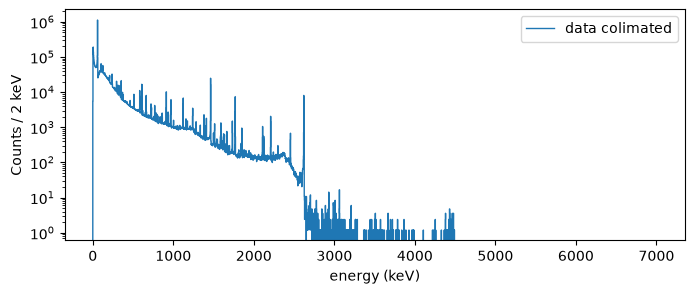

In [25]:
plt.figure(figsize=(8,3))
#plt.stairs(counts_data, bins, label = 'data uncolimated')
plt.stairs(counts_colli, bins, label = 'data colimated')
#plt.stairs(counts_bkg, bins, label = 'bkg (normalized)')
plt.yscale('log')
plt.ylabel(f'Counts / {bins[1]-bins[0]:.0f} keV')
plt.xlabel("energy (keV)")
#plt.vlines(2614, 1, 1e5, color = 'green')
plt.legend()
#plt.xlim(-50,3500)

In [35]:
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    #"gamma_125p3keV": 125.3,
    #"gamma_208p1keV": 208.1,
    #"gamma_335p4keV": 335.4,
    #"gamma_662p4keV": 662.4,
}


for n, e  in peaks.items():
    print(e)

59.9
99.0
103.0
123.1


Reading data and background...
Reading data and background...
Reading data and background...


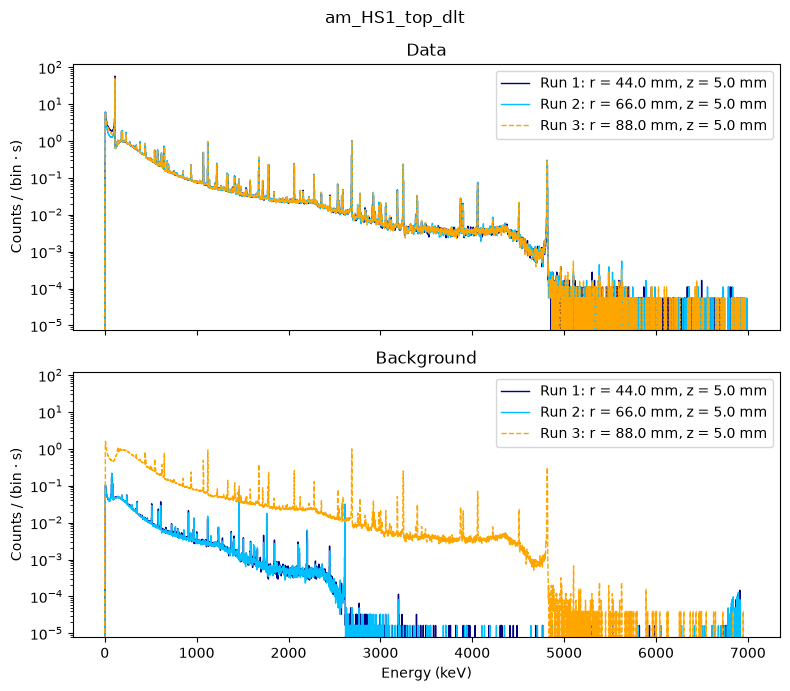

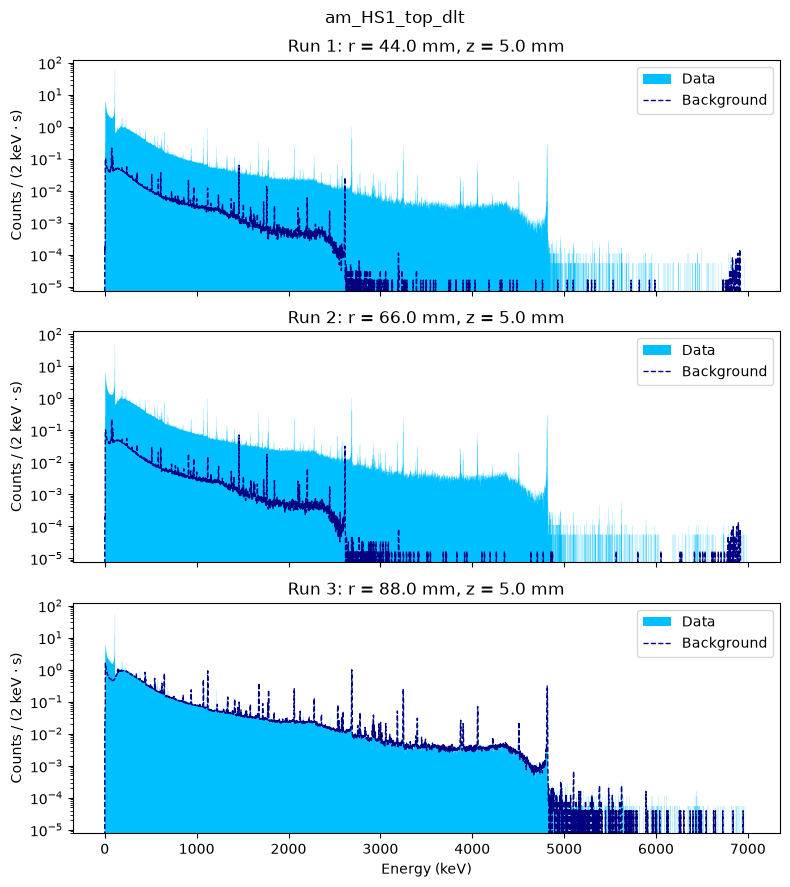

In [302]:
import matplotlib.pyplot as plt
from itertools import cycle

measure = "am_HS1_top_dlt"
runs = ["1", "2", "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)


# ============================================================
# DATA E BACKGROUND: CONFRONTO TRA RUN
# ============================================================

fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, sharey=True
)

colors = cycle(["navy", "deepskyblue", "orange"])
styles = cycle(["-", "-", "--"])

for run, color, ls in zip(runs, colors, styles):
    d = data[run]
    b = bkg[run]
    source = d["source_position"]

    label = (
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )

    axes[0].stairs(
        d["counts_raw"] / d["time_s"],
        d["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

    axes[1].stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

axes[0].set_title("Data")
axes[1].set_title("Background")

for ax in axes:
    ax.set_yscale("log")
    ax.set_ylabel("Counts / (bin · s)")
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()


# ============================================================
# DATA E BACKGROUND: UN PANNELLO PER RUN
# ============================================================

fig, axes = plt.subplots(
    len(runs),
    1,
    figsize=(8, 3 * len(runs)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes[:, 0]

for ax, run in zip(axes, runs):
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    ax.stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color="navy",
        linestyle="--",
        label="Background",
    )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

Reading data and background...
Reading data and background...


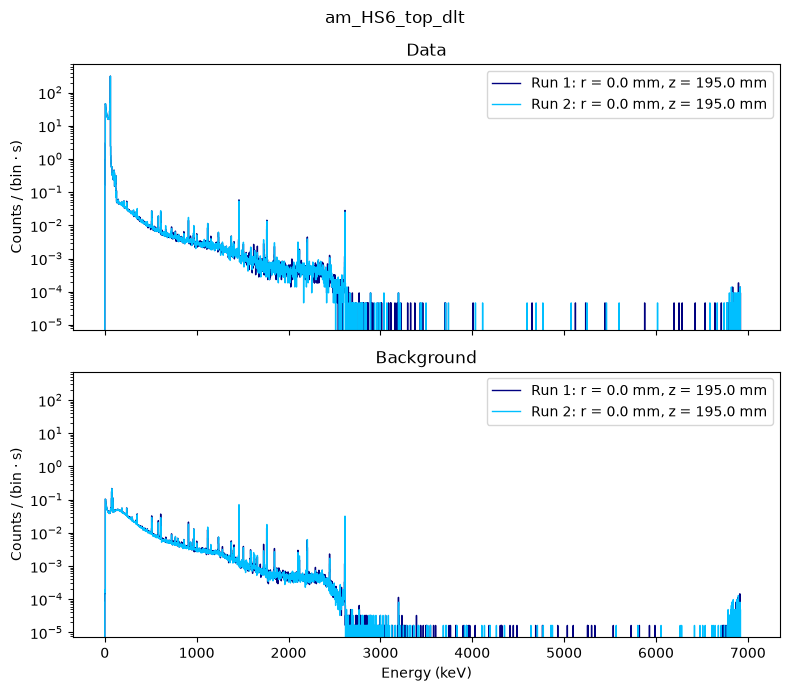

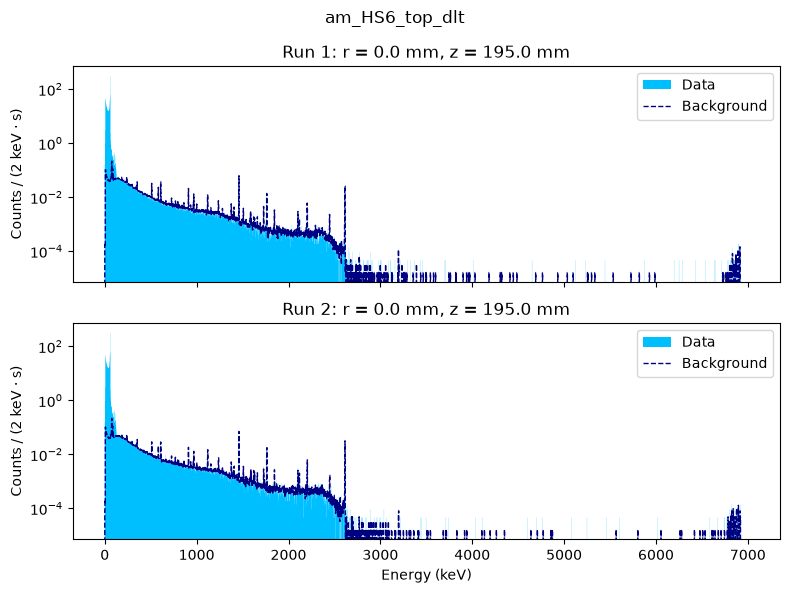

In [304]:
measure = "am_HS6_top_dlt"
runs = ["1", "2"]#, "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)


# ============================================================
# DATA E BACKGROUND: CONFRONTO TRA RUN
# ============================================================

fig, axes = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, sharey=True
)

colors = cycle(["navy", "deepskyblue", "orange"])
styles = cycle(["-", "-", "--"])

for run, color, ls in zip(runs, colors, styles):
    d = data[run]
    b = bkg[run]
    source = d["source_position"]

    label = (
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )

    axes[0].stairs(
        d["counts_raw"] / d["time_s"],
        d["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

    axes[1].stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color=color,
        linestyle=ls,
        label=label,
    )

axes[0].set_title("Data")
axes[1].set_title("Background")

for ax in axes:
    ax.set_yscale("log")
    ax.set_ylabel("Counts / (bin · s)")
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()


# ============================================================
# DATA E BACKGROUND: UN PANNELLO PER RUN
# ============================================================

fig, axes = plt.subplots(
    len(runs),
    1,
    figsize=(8, 3 * len(runs)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes[:, 0]

for ax, run in zip(axes, runs):
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )

    ax.stairs(
        b["counts_raw"] / b["time_s"],
        b["bins"],
        color="navy",
        linestyle="--",
        label="Background",
    )

    ax.set_title(
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_yscale("log")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

axes[-1].set_xlabel("Energy (keV)")
fig.suptitle(measure)
fig.tight_layout()
plt.show()

In [43]:
import matplotlib.pyplot as plt

measure = "am_HS6_top_dlt"
runs = ["1", "2"]#, "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)

# Usa il tuo dizionario peaks: {nome: energia in keV}

# ============================================================
# DATA E BACKGROUND: UN GRAFICO SEPARATO PER RUN
# ============================================================


Reading data and background...
Reading data and background...


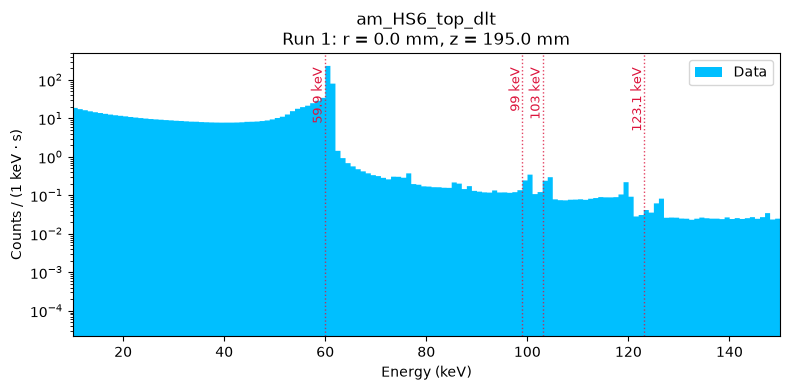

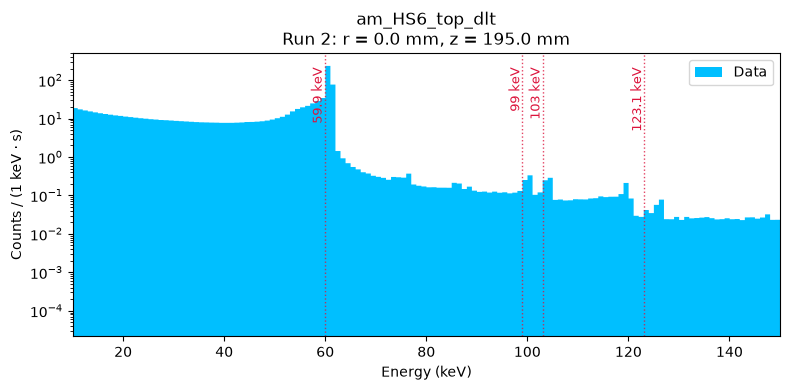

In [44]:

for run in runs:
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )


    for name, energy in peaks.items():
        ax.axvline(
            energy,
            color="crimson",
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

        ax.text(
            energy,
            0.95,
            f"{energy:g} keV",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color="crimson",
        )

    ax.set_title(
        f"{measure}\n"
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_xlim(10,150)
    ax.set_yscale("log")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

    fig.tight_layout()
    plt.show()

In [45]:
import matplotlib.pyplot as plt

measure = "am_HS1_top_dlt"
runs = ["1", "2", "3"]

data = {}
bkg = {}

for run in runs:
    data[run], bkg[run] = open_data(db, run, measure)

# Usa il tuo dizionario peaks: {nome: energia in keV}

# ============================================================
# DATA E BACKGROUND: UN GRAFICO SEPARATO PER RUN
# ============================================================


Reading data and background...
Reading data and background...
Reading data and background...


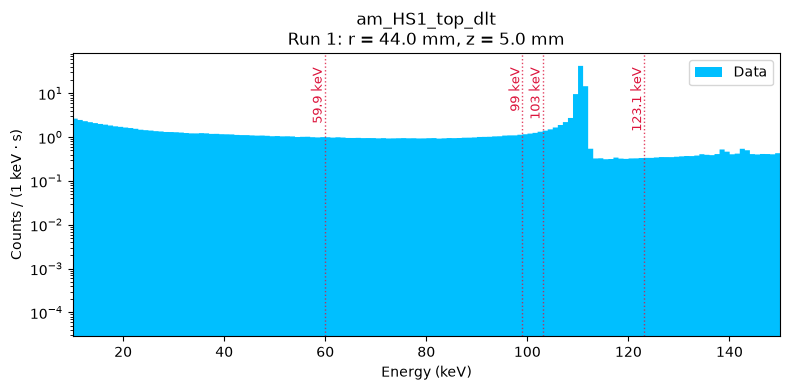

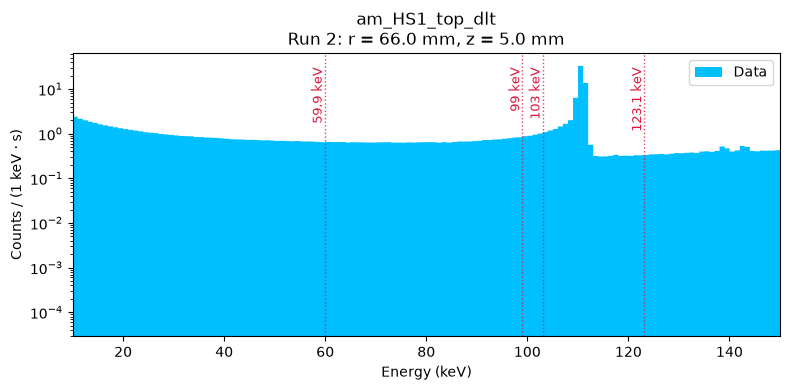

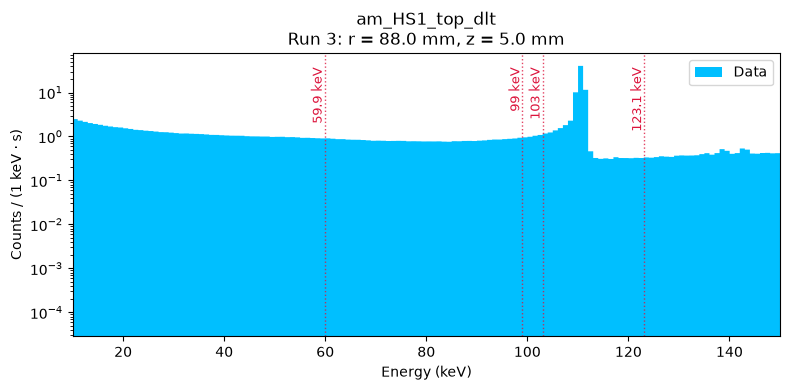

In [46]:

for run in runs:
    d = data[run]
    b = bkg[run]
    edges = d["bins"]
    source = d["source_position"]

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.stairs(
        d["counts_raw"] / d["time_s"],
        edges,
        color="deepskyblue",
        fill=True,
        label="Data",
    )


    for name, energy in peaks.items():
        ax.axvline(
            energy,
            color="crimson",
            linestyle=":",
            linewidth=1,
            alpha=0.8,
        )

        ax.text(
            energy,
            0.95,
            f"{energy:g} keV",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
            color="crimson",
        )

    ax.set_title(
        f"{measure}\n"
        f"Run {run}: r = {source['r_in_mm']} mm, "
        f"z = {source['z_in_mm']} mm"
    )
    ax.set_xlim(10,150)
    ax.set_yscale("log")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel(
        f"Counts / ({edges[1] - edges[0]:.0f} keV · s)"
    )
    ax.legend()

    fig.tight_layout()
    plt.show()

# from pyg4ometry import gdml

if os.path.isfile(gdml_file):
    reg = gdml.Reader(gdml_file).getRegistry()
    print(f"GDML caricato: {gdml_file}")
else:
    raise FileNotFoundError(gdml_file)Simulation

In [239]:
run = "run0001"
config_geom = deepcopy(configuration[run])

gdml_file = os.path.join(
    output_dir, f"{detector}_{measure}_{run}.gdml"
)

if os.path.isfile(gdml_file):
    reg = gdml.Reader(gdml_file).getRegistry()
    print(f"GDML già presente, caricato: {gdml_file}")
else:
    reg = pygeomhades.core.construct(config_geom)
    os.makedirs(output_dir, exist_ok=True)
    write_pygeom(reg, gdml_file)
    print(f"GDML creato: {gdml_file}")

INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_top_thickness
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_cavity_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI_1
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define edge_height
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define pos_top_ring_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define end_top_ring_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define pos_bottom_ring_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define end_bottom_ring_z
INFO:pyg4ometry.gdml.Writer

GDML creato: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS6_top_dlt_run0001.gdml


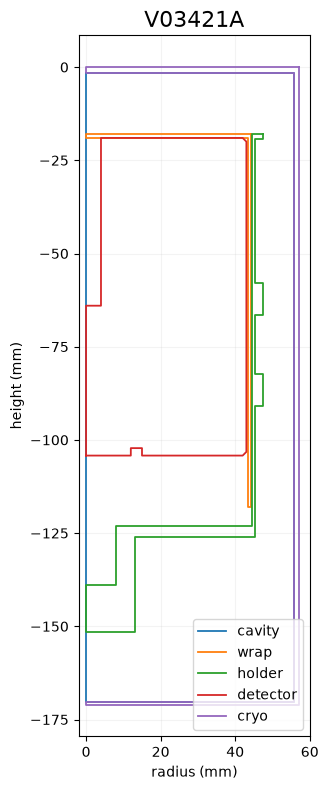

In [167]:

placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(4,8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [168]:
from remage import remage_run



In [178]:
peaks = {
    "gamma_59p9keV": 59.9,
    "gamma_99keV": 99.0,
    "gamma_103keV": 103.0,
    "gamma_123p1keV": 123.1,
    "gamma_125p3keV": 125.3,
    "gamma_208p1keV": 208.1,
    "gamma_335p4keV": 335.4,
    "gamma_662p4keV": 662.4,
}

N_sim = 1_000
force_rerun = False

os.makedirs(output_dir, exist_ok=True)
simulation_files = {}

for name, energy_keV in peaks.items():

    output_file = os.path.join(
        output_dir,
        f"{detector}_{measure}_{run}_{name}.lh5"
    )

    if os.path.isfile(output_file) and not force_rerun:
        simulation_files[name] = output_file
        print(f"✅ {name}: uso il file esistente → {output_file}")
        continue

    macro = [
        "/RMG/Manager/Logging/LogLevel summary",
        "/RMG/Processes/HadronicPhysics Shielding",
        f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",
        "/RMG/Output/NtupleUseVolumeName true",
        "/RMG/Output/NtuplePerDetector false",
        "/run/initialize",
        "/RMG/Generator/Confine Volume",
        "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",
        "/RMG/Generator/Select GPS",
        "/gps/particle gamma",
        "/gps/ene/type Mono",
        f"/gps/energy {energy_keV} keV",
        "/gps/ang/type iso",
        f"/run/beamOn {N_sim}",
    ]

    print(f"▶ {name}: avvio simulazione → {output_file}")

    try:
        remage_run(
            macros=macro,
            gdml_files=gdml_file,
            output=output_file,
            overwrite_output=True,
        )
        simulation_files[name] = output_file
        print(f"✅ {name}: simulazione completata")

    except Exception as e:
        print(f"❌ {name}: {e}")

print("\nFile disponibili:", simulation_files)

▶ gamma_59p9keV: avvio simulazione → /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_59p9keV.lh5
  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading '/global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading '/global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...


[Summary -> CLHEP::HepRandom seed changed to: 1423355806 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: /global/u2/r/ritaferi/HADES_DATA/.rmg-tmp-11867.V03421A_am_HS1_top_dlt_run0001_gamma_59p9keV.hdf5 (for /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_59p9keV.lh5)
[Summary -> Starting run nr. 0. Current local time is 30-09-2026 13:27:53 PDT
[Summary -> Number of events to be processed: 100000000
[Summary -> Processing event nr. 10000000 (10%), at 0 days, 0 hours, 6 minutes and 12 seconds
[Summary -> Processing event nr. 20000000 (20%), at 0 days, 0 hours, 12 minutes and 23 seconds
[Summary -> Processing event nr. 30000000 (30%), at 0 days, 0 hours, 18 minutes and 31 seconds
[Summary -> Processing event nr. 40000000 (40%), at 0 days, 0 hours, 24 minutes and 36 seconds
[Summary -> Processing event nr. 50000000 (50%), at 0 days, 0 hours, 30 minutes and 53 seconds
[Summary -> Processing event nr. 6000000

✅ gamma_59p9keV: simulazione completata
▶ gamma_99keV: avvio simulazione → /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_99keV.lh5


[Summary -> CLHEP::HepRandom seed changed to: 742081284 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...


  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading '/global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading '/global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...


[Summary -> Opening output file: /global/u2/r/ritaferi/HADES_DATA/.rmg-tmp-73173.V03421A_am_HS1_top_dlt_run0001_gamma_99keV.hdf5 (for /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_99keV.lh5)
[Summary -> Starting run nr. 0. Current local time is 30-09-2026 14:30:27 PDT
[Summary -> Number of events to be processed: 100000000
[Summary -> Processing event nr. 10000000 (10%), at 0 days, 0 hours, 6 minutes and 56 seconds
[Summary -> Processing event nr. 20000000 (20%), at 0 days, 0 hours, 13 minutes and 49 seconds
[Summary -> Processing event nr. 30000000 (30%), at 0 days, 0 hours, 20 minutes and 40 seconds
[Summary -> Processing event nr. 40000000 (40%), at 0 days, 0 hours, 27 minutes and 31 seconds
[Summary -> Processing event nr. 50000000 (50%), at 0 days, 0 hours, 34 minutes and 22 seconds
HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5D.c line 1347 in H5Dwrite(): can't synchronously write data
    major: Dataset
    minor: Write failed
  #001: H5D

pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54240000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.
pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54240000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.
pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54240000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.
pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54240000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : Analysis_W001
      issued by : G4TNtupleManager<NT,FT>::AddTNtupleRow
Ntuple 2 adding row has failed.
*** This is just a warning message. ***
-------- WWWW -------- G4Exception-END --------- WWWW -------



HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5D.c line 1347 in H5Dwrite(): can't synchronously write data
    major: Dataset
    minor: Write failed
  #001: H5D.c line 1294 in H5D__write_api_common(): can't write data
    major: Dataset
    minor: Write failed
  #002: H5VLcallback.c line 2201 in H5VL_dataset_write(): dataset write failed
    major: Virtual Object Layer
    minor: Write failed
  #003: H5VLcallback.c line 2157 in H5VL__dataset_write(): dataset write failed
    major: Virtual Object Layer
    minor: Write failed
  #004: H5VLnative_dataset.c line 421 in H5VL__native_dataset_write(): can't write data
    major: Dataset
    minor: Write failed
  #005: H5Dio.c line 826 in H5D__write(): can't write data
    major: Dataset
    minor: Write failed
  #006: H5Dchunk.c line 3289 in H5D__chunk_write(): unable to read raw data chunk
    major: Low-level I/O
    minor: Read failed
  #007: H5Dchunk.c line 4620 in H5D__chunk_lock(): unable to preempt chunk(s) from cache

pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54272000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.
pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54272000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : Analysis_W001
      issued by : G4TNtupleManager<NT,FT>::AddTNtupleRow
Ntuple 2 adding row has failed.
*** This is just a warning message. ***
-------- WWWW -------- G4Exception-END --------- WWWW -------

pages::write_page : write_append_array_dataset<TYPE>() failed. Pos 54272000
toolx::hdf5::ntuple::column_ref::add : write_page() failed.
❌ gamma_99keV: error while running remage-cpp
▶ gamma_103keV: avvio simulazione → /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_103keV.lh5
❌ gamma_103keV: error while running remage-cpp
▶ gamma_123p1keV: avvio simulazione → /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_r

In [170]:
N_sim_by_peak = {}
energies = ["gamma_59p9keV", "gamma_99keV","gamma_103keV",
    "gamma_123p1keV",
    "gamma_125p3keV",
    "gamma_208p1keV",
    "gamma_335p4keV"]

for name in energies:
    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{run}_{name}.lh5"
    )

    obj = lh5.read("number_of_simulated_events", filename)

    # Compatibilità con versioni che restituiscono una tupla
    if isinstance(obj, tuple):
        obj = obj[0]

    N_sim_by_peak[name] = int(obj.value)
    print(f"{name}: {N_sim_by_peak[name]:,} eventi simulati")

gamma_59p9keV: 50,000,000 eventi simulati
gamma_99keV: 50,000,000 eventi simulati
gamma_103keV: 50,000,000 eventi simulati
gamma_123p1keV: 50,000,000 eventi simulati
gamma_125p3keV: 50,000,000 eventi simulati
gamma_208p1keV: 50,000,000 eventi simulati
gamma_335p4keV: 50,000,000 eventi simulati


PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_59p9keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_99keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_103keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_123p1keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_125p3keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_208p1keV.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_am_HS1_top_dlt_run0001_gamma_335p4keV.lh5 | esiste: True


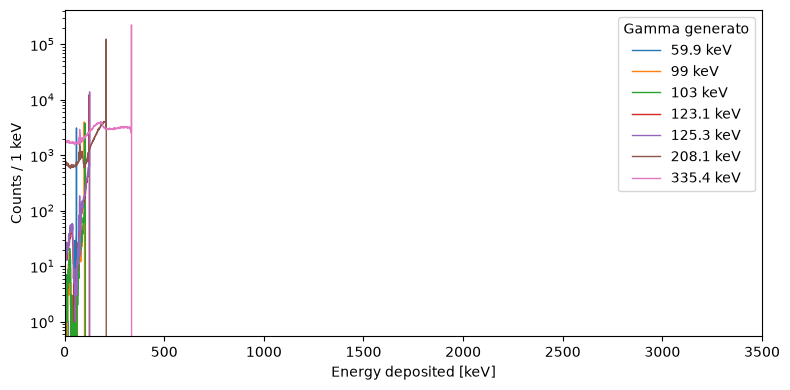

In [171]:
fig, ax = plt.subplots(figsize=(8, 4))
has_counts = False

for i, (name, energy_keV) in enumerate(peaks.items()):

    filename = simulation_files.get(
        name,
        os.path.join(
            output_dir,
            f"{detector}_{measure}_{run}_{name}.lh5"
        )
    )

    print("PATH:", filename, "| esiste:", os.path.isfile(filename))

    try:
        data = lh5.read_as("stp/germanium", filename, "ak")
        energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
        energy = energy[energy > 0]

        counts, _ = np.histogram(energy, bins=bins)

        if counts.sum() == 0:
            print(f"{name}: nessun deposito nell'intervallo del grafico")
            continue

        ax.stairs(
            counts,
            bins,
            #color=colors[i % len(colors)],
            label=f"{energy_keV:g} keV"
        )
        has_counts = True

    except Exception:
        print(f"Errore durante la lettura o il grafico di {name}:")
        traceback.print_exc()

if has_counts:
    ax.set_xlabel("Energy deposited [keV]")
    ax.set_ylabel("Counts / 1 keV")
    ax.set_xlim(emin, emax)
    ax.set_yscale("log")
    ax.legend(title="Gamma generato")
    fig.tight_layout()
    plt.show()
else:
    plt.close(fig)
    print("Nessun conteggio da mostrare")

In [172]:
BR = {
    "gamma_59p9keV":  0.359,
    "gamma_99keV":    2.03e-4,
    "gamma_103keV":   1.95e-4,
    "gamma_123p1keV": 1.00e-5,
    "gamma_125p3keV": 4.08e-5,
    "gamma_208p1keV": 7.91e-6,
    "gamma_335p4keV": 4.96e-6,
}


In [173]:

activity = 4330e3  # Bq: valore nominale comune alla misura

counts_theory = np.zeros(len(bins) - 1)
counts_smeared = np.zeros(len(bins) - 1)

for name, br in BR.items():

    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{run}_{name}.lh5"
    )

    # Gli errori di lettura vengono mostrati, evitando somme incomplete
    data = lh5.read_as("stp/germanium", filename, "ak")
    energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
    energy = energy[energy > 0]

    if len(energy) == 0:
        print(f"{name}: nessun deposito positivo di energia")
        continue

    energy_smeared = ak.to_numpy(
        reboost.math.stats.gaussian_sample(energy, sigma=1)
    )

    N_sim = N_sim_by_peak[name]
    if N_sim <= 0:
        raise ValueError(f"{name}: N_sim deve essere positivo")

    # BR applicato una sola volta, nel peso
    peso = activity * time_measurement * br / N_sim
    weights = np.full(len(energy), peso)

    counts_iso, _ = np.histogram(
        energy, bins=bins, weights=weights
    )
    counts_iso_smeared, _ = np.histogram(
        energy_smeared, bins=bins, weights=weights
    )

    counts_theory += counts_iso
    counts_smeared += counts_iso_smeared

    print(f"{name}: N_sim = {N_sim:,}, peso = {peso:.6g}")

counts_MC = counts_smeared

gamma_59p9keV: N_sim = 50,000,000, peso = 559.609
gamma_99keV: N_sim = 50,000,000, peso = 0.316436
gamma_103keV: N_sim = 50,000,000, peso = 0.303966
gamma_123p1keV: N_sim = 50,000,000, peso = 0.015588
gamma_125p3keV: N_sim = 50,000,000, peso = 0.063599
gamma_208p1keV: N_sim = 50,000,000, peso = 0.0123301
gamma_335p4keV: N_sim = 50,000,000, peso = 0.00773165


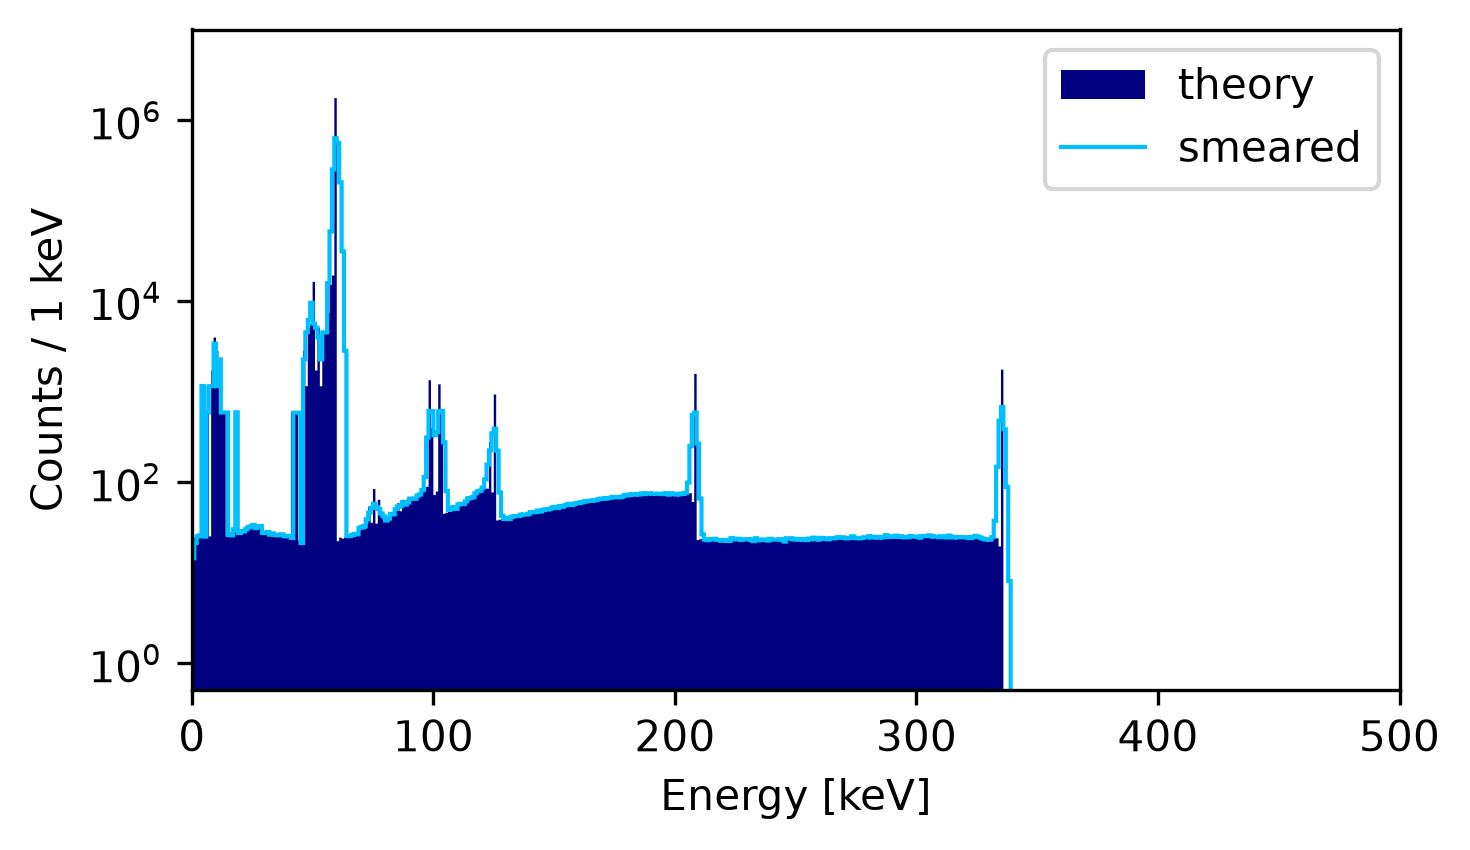

In [174]:
plt.figure(figsize=(5,3), dpi = 300)

plt.stairs(
    counts_theory,
    bins,
    fill = True,
    color="navy",
    label="theory"
)

plt.stairs(
    counts_smeared,
    bins,
    color="deepskyblue",
    label="smeared")

plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bins[1]-bins[0]:.0f} keV")
plt.ylim(0.5, 1e7)
plt.yscale("log")
plt.xlim(0, 500)
#plt.vlines(59.9, 1, 100000, color = 'orange')
#plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

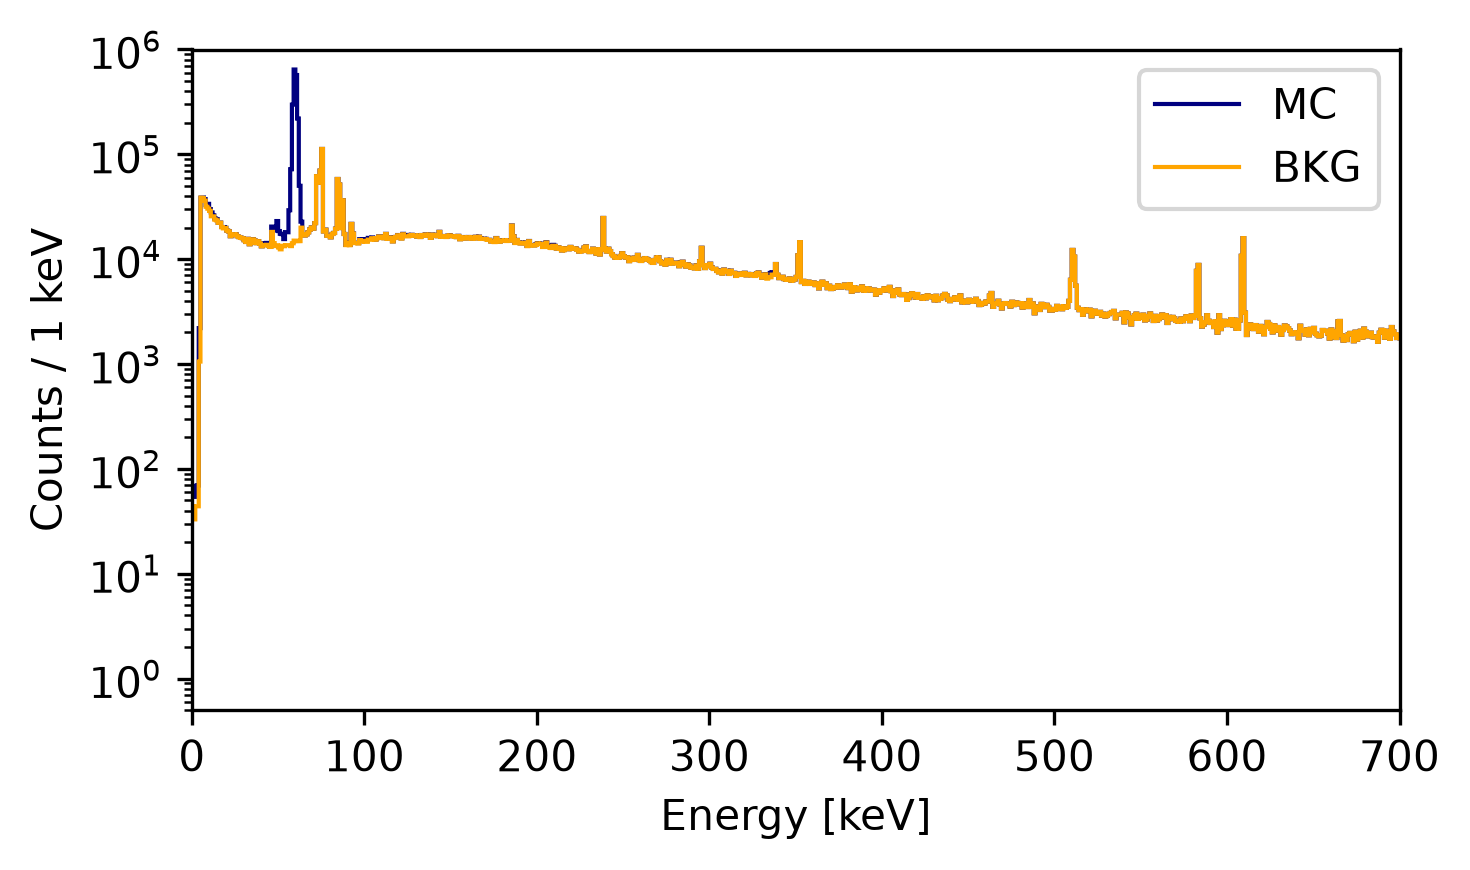

In [175]:
plt.figure(figsize=(5,3), dpi = 300)

plt.stairs(
    counts_smeared + counts_bkg,
    bins,
    #fill = True,
    color="navy",
    label="MC"
)

plt.stairs(
    counts_bkg,
    bins,
    #fill = True,
    color="orange",
    label="BKG"
)


plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bins[1]-bins[0]:.0f} keV")
plt.ylim(0.5, 1e6)
plt.yscale("log")
#plt.vlines(59.9, 1, 100000, color = 'orange')
#plt.grid(alpha=0.25)
plt.legend()
plt.xlim(emin, 700)
plt.tight_layout()
plt.show()

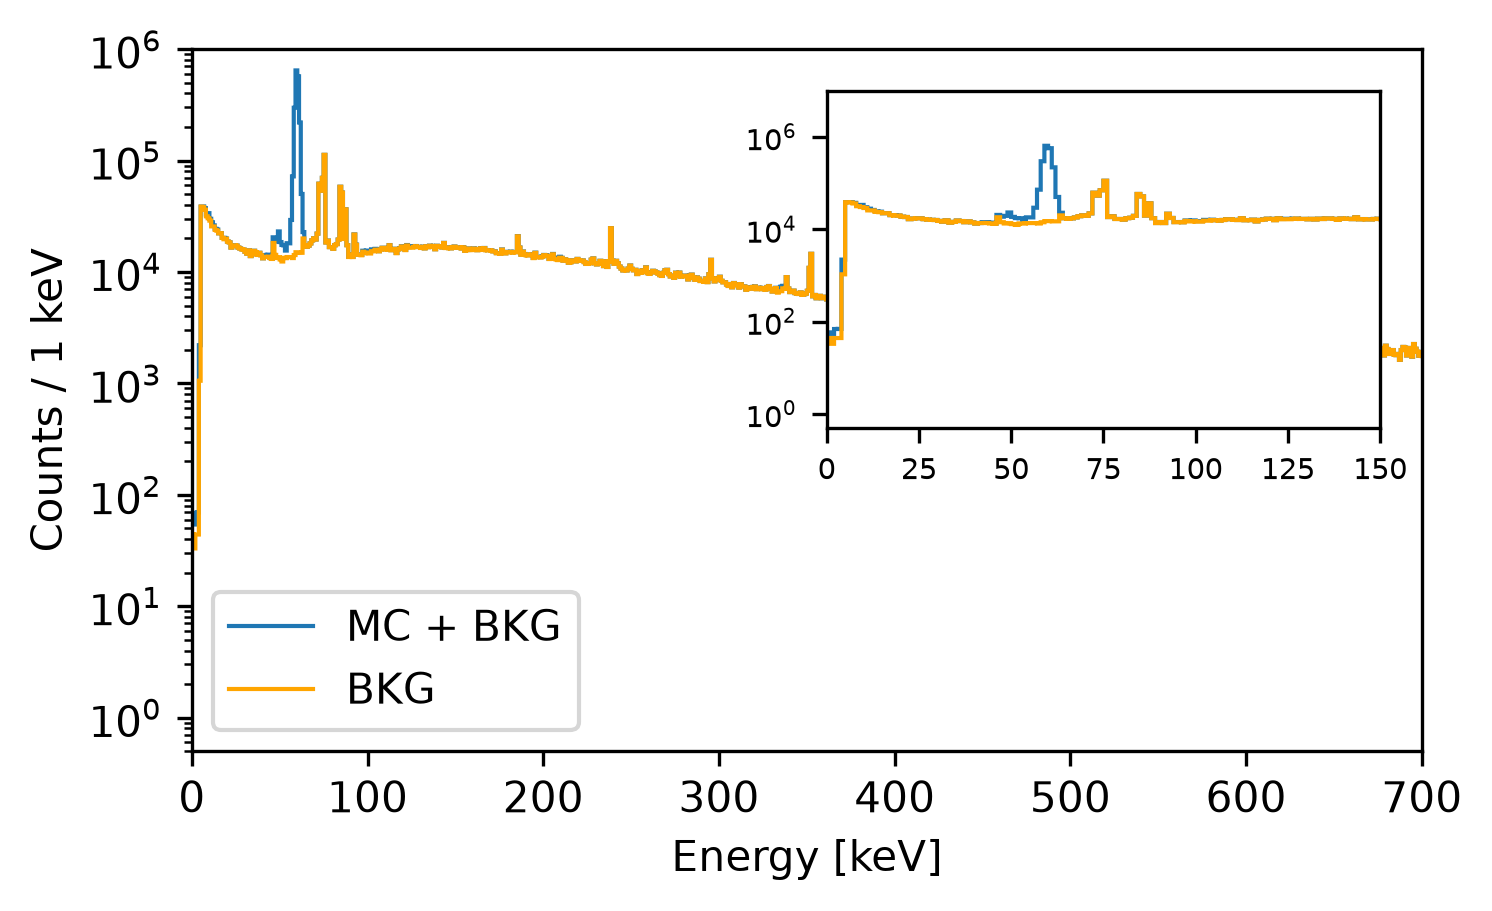

In [176]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

ax.stairs(
    counts_smeared + counts_bkg,
    bins,
    #color="navy",
    label="MC + BKG"
)

ax.stairs(
    counts_bkg,
    bins,
    color="orange",
    label="BKG"
)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(f"Counts / {bins[1] - bins[0]:g} keV")
ax.set_ylim(0.5, 1e6)
ax.set_yscale("log")
ax.set_xlim(emin, 700)
ax.legend(loc="lower left")

# Inset: 0–150 keV
axins = inset_axes(
    ax,
    width="45%",
    height="48%",
    loc="upper right",
    borderpad=1
)

axins.stairs(
    counts_smeared + counts_bkg,
    bins,
    #color="navy"
)

axins.stairs(
    counts_bkg,
    bins,
    color="orange"
)

axins.set_xlim(0, 150)
axins.set_ylim(0.5, 1e7)
axins.set_yscale("log")
axins.tick_params(axis="both", labelsize=7)
#axins.set_title("0–150 keV", fontsize=8)

fig.subplots_adjust(left=0.15, bottom=0.18, right=0.97, top=0.96)
plt.show()

# data comparison

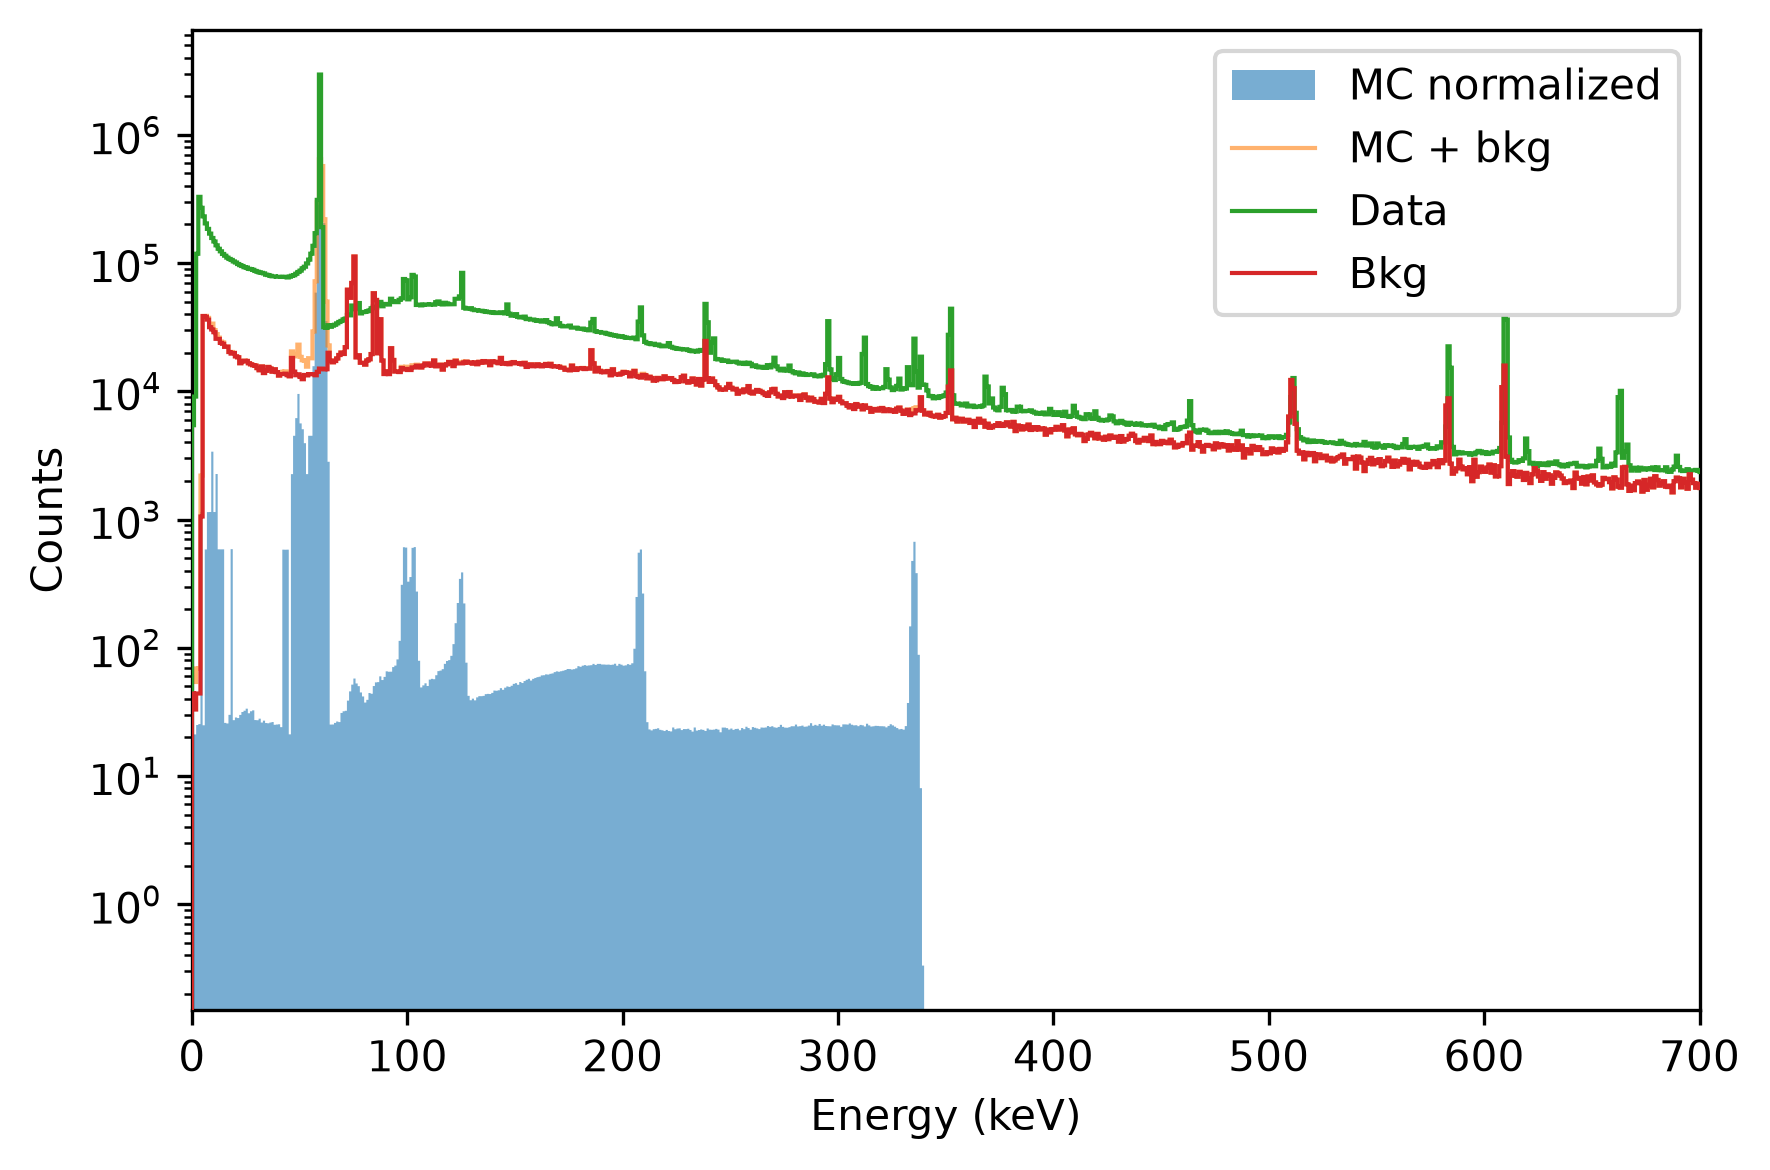

In [177]:

plt.figure(figsize=(6,4), dpi = 300)

plt.stairs(
    counts_MC , 
    bins,
    fill = True,
    alpha = 0.6,
    label="MC normalized"
)

plt.stairs(
    counts_MC + counts_bkg, 
    bins,
    #fill = True,
    alpha = 0.6,
    label="MC + bkg"
)



plt.stairs(
    counts_data,
    bins,
    #fill = True,
    #color="deepskyblue",
    label="Data",
    zorder = 10
)

plt.stairs(
    counts_bkg,
    bins,
    label="Bkg",
    zorder = 10
)



plt.xlim(0, 700)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

#ùplt.vlines(2614, 1, 1e5, color = 'red')

plt.tight_layout()
plt.show()


